## PROJETO FINAL

**Autor:** Ervin Alain Bolivar Huayhua,

**Data:** 26 de Nov de 2025",

**Disciplina:** IA368 - Tópicos em Engenharia de Computação V,

**Professores:** Roberto Lotufo, Jayr Pereira, Diedre do Carmo

In [31]:
# ============================================
# TREINAMENTO E AVALIAÇÃO V7
# ============================================

import os
import io
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
import librosa
import soundfile as sf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from gtts import gTTS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 1. CARREGAR E BALANCEAR DATASET

In [32]:
print("Carregando dataset V7...")

with open('addressee_dataset_v7.pkl', 'rb') as f:
    data = pickle.load(f)

all_data = data['data']
print(f"Total: {len(all_data)}")
print(f"ADDRESSED: {data['n_addressed']}")
print(f"NOT_ADDRESSED: {data['n_not_addressed']}")

# Balancear classes
addressed = [d for d in all_data if d['label'] == 'ADDRESSED']
not_addressed = [d for d in all_data if d['label'] == 'NOT_ADDRESSED']

n_balanced = min(len(addressed), len(not_addressed))
balanced_data = addressed[:n_balanced] + not_addressed[:n_balanced]
np.random.seed(42)
np.random.shuffle(balanced_data)

print(f"Balanceado: {len(balanced_data)} amostras ({n_balanced} por classe)")


Carregando dataset V7...
Total: 186
ADDRESSED: 98
NOT_ADDRESSED: 88
Balanceado: 176 amostras (88 por classe)


## 2. EXTRAIR EMBEDDINGS


In [33]:
def extract_embedding(audio_array, sr=16000, n_mfcc=40):
    """Extrai características MFCC do áudio."""
    if len(audio_array) < sr:
        audio_array = np.pad(audio_array, (0, sr - len(audio_array)))
    mfcc = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1), mfcc.max(axis=1), mfcc.min(axis=1)])

print("\nExtraindo embeddings...")

embeddings = []
labels = []

for sample in tqdm(balanced_data, desc="MFCC"):
    emb = extract_embedding(sample['audio'])
    embeddings.append(emb)
    labels.append(sample['label_numeric'])

embeddings = np.array(embeddings)
labels = np.array(labels)

print(f"Embeddings shape: {embeddings.shape}")



Extraindo embeddings...


MFCC: 100%|██████████| 176/176 [00:01<00:00, 162.51it/s]

Embeddings shape: (176, 160)


## 3. VISUALIZAÇÃO T-SNE



Gerando visualização t-SNE...


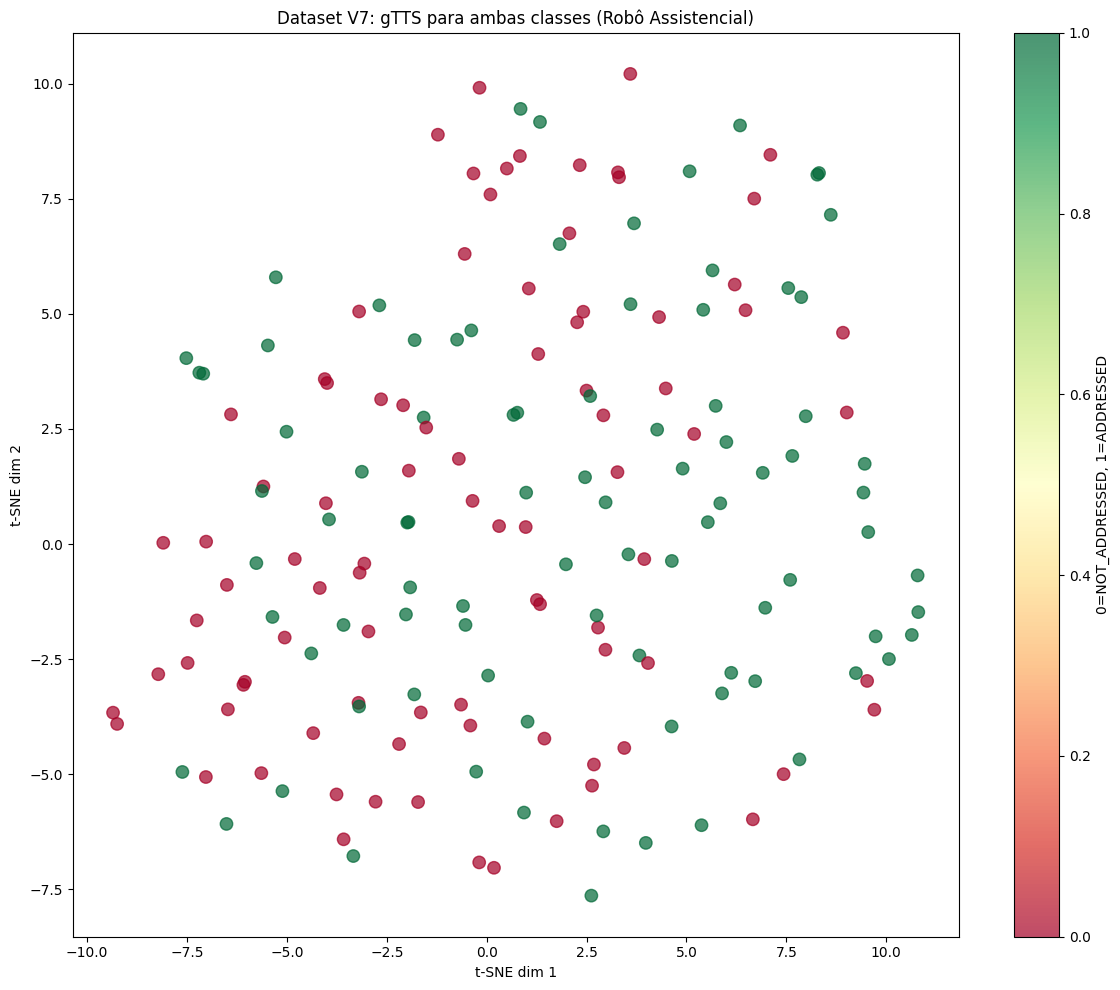

In [34]:
print("\nGerando visualização t-SNE...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='RdYlGn', alpha=0.7, s=80)
plt.colorbar(scatter, label='0=NOT_ADDRESSED, 1=ADDRESSED')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.title('Dataset V7: gTTS para ambas classes (Robô Assistencial)')
plt.tight_layout()
plt.savefig('tsne_v7.png', dpi=150)
plt.show()

## 4. DIVISÃO DOS DADOS E TREINAMENTO

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTreino: {len(y_train)}, Teste: {len(y_test)}")

class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(AudioDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(AudioDataset(X_test, y_test), batch_size=16, shuffle=False)

class AddresseeClassifierV7(nn.Module):
    def __init__(self, input_dim=160):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        return self.net(x)

model = AddresseeClassifierV7(input_dim=embeddings.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Modelo: {sum(p.numel() for p in model.parameters()):,} parâmetros")



Treino: 140, Teste: 36
Modelo: 31,394 parâmetros


### Loop de treinamento


In [36]:
train_losses = []
test_accuracies = []
best_accuracy = 0

print("\nTreinando modelo...")

for epoch in range(150):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    # Avaliação no conjunto de teste
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch).argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
    
    accuracy = correct / total
    test_accuracies.append(accuracy)
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model_v7.pth')
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} - Loss: {train_losses[-1]:.4f} - Acc: {accuracy:.4f}")

print(f"\nMelhor accuracy: {best_accuracy:.4f}")

# Carregar melhor modelo
model.load_state_dict(torch.load('best_model_v7.pth'))




Treinando modelo...
Epoch  25 - Loss: 0.0409 - Acc: 0.7222
Epoch  50 - Loss: 0.0627 - Acc: 0.6389
Epoch  75 - Loss: 0.0230 - Acc: 0.8333
Epoch 100 - Loss: 0.0226 - Acc: 0.7778
Epoch 125 - Loss: 0.0278 - Acc: 0.8611
Epoch 150 - Loss: 0.0255 - Acc: 0.8611

Melhor accuracy: 0.8611


<All keys matched successfully>

## 5. GRÁFICOS DE TREINAMENTO

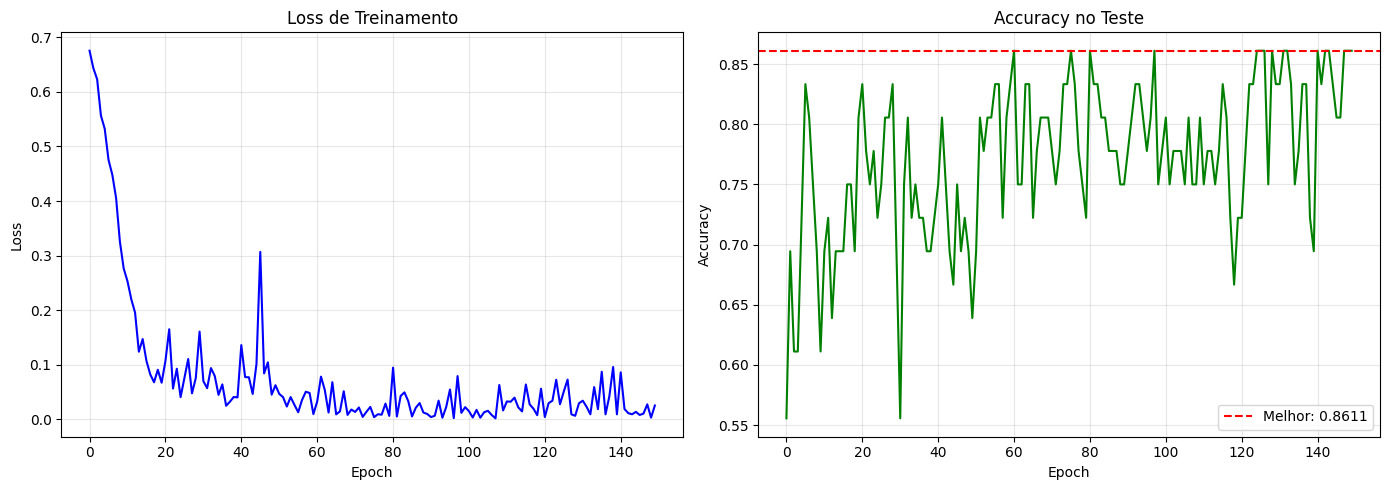

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss de Treinamento')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_accuracies, color='green')
axes[1].axhline(y=best_accuracy, color='red', linestyle='--', label=f'Melhor: {best_accuracy:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy no Teste')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_v7.png', dpi=150)
plt.show()

## 6. AVALIAÇÃO NO CONJUNTO DE TESTE

In [38]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

print("\n" + "=" * 70)
print("AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 70)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n" + classification_report(all_labels, all_preds, target_names=['NOT_ADDRESSED', 'ADDRESSED']))

cm = confusion_matrix(all_labels, all_preds)
print("Matriz de Confusão:")
print(f"              Pred:NOT  Pred:ADDR")
print(f"Real:NOT         {cm[0,0]:3d}        {cm[0,1]:3d}")
print(f"Real:ADDR        {cm[1,0]:3d}        {cm[1,1]:3d}")



AVALIAÇÃO NO CONJUNTO DE TESTE
Accuracy:  0.8611
Precision: 0.8421
Recall:    0.8889
F1-Score:  0.8649

               precision    recall  f1-score   support

NOT_ADDRESSED       0.88      0.83      0.86        18
    ADDRESSED       0.84      0.89      0.86        18

     accuracy                           0.86        36
    macro avg       0.86      0.86      0.86        36
 weighted avg       0.86      0.86      0.86        36

Matriz de Confusão:
              Pred:NOT  Pred:ADDR
Real:NOT          15          3
Real:ADDR          2         16


## 7. AVALIAÇÃO COM ÁUDIO NOVO (IMPORTANTE!)


In [39]:
print("\n" + "=" * 70)
print("AVALIAÇÃO COM ÁUDIO NOVO (frases NÃO vistas no treino)")
print("=" * 70)

def generate_gtts_audio(text, sr=16000):
    """Gera áudio usando Google Text-to-Speech."""
    tts = gTTS(text=text, lang='en')
    fp = io.BytesIO()
    tts.write_to_fp(fp)
    fp.seek(0)
    audio, orig_sr = sf.read(fp)
    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)
    if orig_sr != sr:
        audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=sr)
    audio = audio.astype(np.float32)
    if np.abs(audio).max() > 0:
        audio = audio / np.abs(audio).max()
    return audio

def classify_audio(audio_array):
    """Classifica um array de áudio."""
    embedding = extract_embedding(audio_array)
    tensor = torch.FloatTensor(embedding).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        pred = output.argmax(dim=1).item()
    return {
        'label': 'ADDRESSED' if pred == 1 else 'NOT_ADDRESSED',
        'confidence': probs[0, pred].item()
    }

# Frases NOVAS não vistas no treinamento
NEW_TESTS = [
    # ADDRESSED - Comandos diretos ao robô
    ("Robot please help me stand up now", "ADDRESSED"),
    ("Can you bring me my medicine bottle", "ADDRESSED"),
    ("Turn the lights on in the kitchen", "ADDRESSED"),
    ("I need you to call my son please", "ADDRESSED"),
    ("What is the temperature right now", "ADDRESSED"),
    ("Please close the door it is cold", "ADDRESSED"),
    ("Help me walk to the living room", "ADDRESSED"),
    ("Read my messages out loud please", "ADDRESSED"),
    
    # NOT_ADDRESSED - Falas não direcionadas ao robô
    ("I wonder where my grandchildren are now", "NOT_ADDRESSED"),
    ("This movie is really quite boring", "NOT_ADDRESSED"),
    ("Maybe I should have taken that job", "NOT_ADDRESSED"),
    ("The flowers in the garden look lovely", "NOT_ADDRESSED"),
    ("I remember when we used to dance together", "NOT_ADDRESSED"),
    ("Tell your mother I miss her very much", "NOT_ADDRESSED"),
    ("The news said it will rain tomorrow", "NOT_ADDRESSED"),
    ("Such a good boy you are my little dog", "NOT_ADDRESSED"),
]

print("\nGerando e classificando áudio novo...")

results = []
for text, expected in tqdm(NEW_TESTS, desc="Testando"):
    audio = generate_gtts_audio(text)
    result = classify_audio(audio)
    correct = result['label'] == expected
    results.append({
        'text': text,
        'expected': expected,
        'predicted': result['label'],
        'correct': correct,
        'confidence': result['confidence']
    })

print(f"\n{'Texto':<45} {'Esperado':<15} {'Predito':<15} {'Conf':<8} {'OK?'}")
print("-" * 90)

for r in results:
    status = "✓" if r['correct'] else "✗"
    print(f"{r['text'][:44]:<45} {r['expected']:<15} {r['predicted']:<15} {r['confidence']:.2%}   {status}")

# Métricas do áudio novo
total_correct = sum(r['correct'] for r in results)
addr_results = [r for r in results if r['expected'] == 'ADDRESSED']
not_addr_results = [r for r in results if r['expected'] == 'NOT_ADDRESSED']

print(f"\n--- Resumo Áudio Novo ---")
print(f"Accuracy total: {total_correct}/{len(results)} ({total_correct/len(results):.2%})")
print(f"ADDRESSED:     {sum(r['correct'] for r in addr_results)}/{len(addr_results)}")
print(f"NOT_ADDRESSED: {sum(r['correct'] for r in not_addr_results)}/{len(not_addr_results)}")



AVALIAÇÃO COM ÁUDIO NOVO (frases NÃO vistas no treino)

Gerando e classificando áudio novo...


Testando: 100%|██████████| 16/16 [00:17<00:00,  1.07s/it]


Texto                                         Esperado        Predito         Conf     OK?
------------------------------------------------------------------------------------------
Robot please help me stand up now             ADDRESSED       ADDRESSED       100.00%   ✓
Can you bring me my medicine bottle           ADDRESSED       ADDRESSED       100.00%   ✓
Turn the lights on in the kitchen             ADDRESSED       ADDRESSED       100.00%   ✓
I need you to call my son please              ADDRESSED       ADDRESSED       100.00%   ✓
What is the temperature right now             ADDRESSED       ADDRESSED       100.00%   ✓
Please close the door it is cold              ADDRESSED       ADDRESSED       100.00%   ✓
Help me walk to the living room               ADDRESSED       ADDRESSED       100.00%   ✓
Read my messages out loud please              ADDRESSED       ADDRESSED       100.00%   ✓
I wonder where my grandchildren are now       NOT_ADDRESSED   ADDRESSED       100.00%   ✗
This mo

## 8. SALVAR MODELO FINAL


In [ ]:

torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': embeddings.shape[1],
    'accuracy': best_accuracy
}, 'addressee_classifier_v7.pth')

print("\nModelo salvo: addressee_classifier_v7.pth")


Modelo salvo: addressee_classifier_v7.pth


# ============================================
# PIPELINE B: Audio → Whisper → LLM
# Robô Assistencial com Classificação Semântica
# ============================================


In [41]:

import os
import io
import time
import json
import numpy as np
import soundfile as sf
import librosa
from dotenv import load_dotenv
from gtts import gTTS
from groq import Groq


### CONFIGURAÇÃO


In [42]:
load_dotenv()
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
client = Groq(api_key=GROQ_API_KEY)

### PROMPT DO SISTEMA

In [43]:

SYSTEM_PROMPT = """You are an AI assistant for a caregiving robot that helps people with disabilities in a smart home.

The robot assists:
- People without hands/arms
- Elderly people with mobility issues
- People with visual impairment
- People with hearing impairment

The robot can:
- Physical assistance (help stand up, walk, sit down, lift)
- IoT control (lights, temperature, windows, doors, TV)
- Bring objects (water, medicine, remote, food)
- Communication (make calls, read messages, send messages)
- Companionship (talk, tell stories, provide comfort)
- Emergency assistance (call for help, alert caregivers)

Your task is to analyze the transcribed speech and determine:
1. Is this speech ADDRESSED to the robot (expecting response/action)?
2. Or is it NOT_ADDRESSED (thinking aloud, talking to someone else, TV background)?

ADDRESSED examples:
- "Can you help me stand up" → User looking at robot, requesting physical help
- "Turn on the lights" → Command for the robot
- "What time is it" → Question expecting robot's answer

NOT_ADDRESSED examples:
- "I wonder where my keys are" → Thinking aloud, not expecting robot action
- "Tell your mother I said hello" → Talking to a human visitor
- "The weather tomorrow will be sunny" → TV/radio background noise
- "Such a good boy" → Talking to a pet

Respond in this exact JSON format:
{
    "classification": "ADDRESSED" or "NOT_ADDRESSED",
    "confidence": "HIGH" or "MEDIUM" or "LOW",
    "reasoning": "Brief explanation",
    "response": "Your response to the user if ADDRESSED, or null if NOT_ADDRESSED"
}

If ADDRESSED, provide a helpful, warm response appropriate for assisting someone with disabilities.
If NOT_ADDRESSED, set response to null and do not interfere."""


### FUNÇÕES DO PIPELINE

In [44]:
def transcribe_audio(audio_array, sr=16000):
    """Transcreve áudio usando Whisper da Groq."""
    
    temp_path = "/tmp/temp_audio.wav"
    sf.write(temp_path, audio_array, sr)
    
    try:
        with open(temp_path, "rb") as audio_file:
            transcription = client.audio.transcriptions.create(
                model="whisper-large-v3",
                file=audio_file,
                language="en"
            )
        return transcription.text
    except Exception as e:
        print(f"Erro no Whisper: {e}")
        return None


def classify_and_respond(text):
    """Classifica o texto e gera resposta se for ADDRESSED."""
    
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Transcribed speech: \"{text}\""}
            ],
            temperature=0.1,
            max_tokens=300
        )
        
        result_text = response.choices[0].message.content
        
        # Limpar possíveis markdown e parsear JSON
        result_text = result_text.replace("```json", "").replace("```", "").strip()
        result = json.loads(result_text)
        
        return result
    
    except Exception as e:
        print(f"Erro no LLM: {e}")
        return {
            "classification": "ERROR",
            "confidence": "LOW",
            "reasoning": str(e),
            "response": None
        }


def process_audio(audio_array, sr=16000):
    """Pipeline completo: Audio → Whisper → LLM."""
    
    start_time = time.time()
    
    # 1. Transcrever
    transcription = transcribe_audio(audio_array, sr)
    whisper_time = time.time() - start_time
    
    if transcription is None:
        return {
            "transcription": None,
            "classification": "ERROR",
            "response": None,
            "times": {"whisper": whisper_time, "llm": 0}
        }
    
    # 2. Classificar e responder
    start_llm = time.time()
    result = classify_and_respond(transcription)
    llm_time = time.time() - start_llm
    
    return {
        "transcription": transcription,
        "classification": result.get("classification"),
        "confidence": result.get("confidence"),
        "reasoning": result.get("reasoning"),
        "response": result.get("response"),
        "times": {
            "whisper": whisper_time * 1000,
            "llm": llm_time * 1000,
            "total": (time.time() - start_time) * 1000
        }
    }

# FUNÇÃO AUXILIAR: Gerar áudio de teste


In [ ]:

def generate_test_audio(text, sr=16000):
    """Gera áudio com gTTS para testes."""
    tts = gTTS(text=text, lang='en')
    fp = io.BytesIO()
    tts.write_to_fp(fp)
    fp.seek(0)
    audio, orig_sr = sf.read(fp)
    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)
    if orig_sr != sr:
        audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=sr)
    return audio.astype(np.float32)

# TESTE DO PIPELINE

print("=" * 70)
print("PIPELINE B: Audio → Whisper → LLM")
print("=" * 70)

# Casos de teste
TEST_CASES = [
    # ADDRESSED - Comandos diretos ao robô
    ("Can you help me stand up please", "ADDRESSED"),
    ("Turn on the lights in the bedroom", "ADDRESSED"),
    ("What time is it now", "ADDRESSED"),
    ("Please bring me a glass of water", "ADDRESSED"),
    ("I am feeling sad can we talk", "ADDRESSED"),
    ("Call my daughter please", "ADDRESSED"),
    
    # NOT_ADDRESSED - Falas não direcionadas ao robô
    ("I wonder where I put my glasses", "NOT_ADDRESSED"),
    ("Tell your mother I said hello", "NOT_ADDRESSED"),
    ("This movie is really boring", "NOT_ADDRESSED"),
    ("The weather tomorrow will be sunny", "NOT_ADDRESSED"),
    ("Such a good boy you are my little dog", "NOT_ADDRESSED"),
    ("I should call Maria tomorrow", "NOT_ADDRESSED"),
]

print("\nTestando pipeline...\n")

results = []
for text, expected in TEST_CASES:
    print(f"Entrada: \"{text}\"")
    
    # Gerar áudio
    audio = generate_test_audio(text)
    
    # Processar
    result = process_audio(audio)
    
    correct = result['classification'] == expected
    results.append({
        'text': text,
        'expected': expected,
        'predicted': result['classification'],
        'correct': correct,
        'confidence': result.get('confidence', 'N/A'),
        'response': result.get('response'),
        'times': result['times']
    })
    
    status = "✓" if correct else "✗"
    print(f"  Transcrição: \"{result['transcription']}\"")
    print(f"  Classificação: {result['classification']} ({result.get('confidence', 'N/A')}) {status}")
    print(f"  Tempo: Whisper {result['times']['whisper']:.0f}ms + LLM {result['times']['llm']:.0f}ms = {result['times']['total']:.0f}ms")
    
    if result['classification'] == 'ADDRESSED' and result.get('response'):
        print(f"  Resposta: \"{result['response'][:80]}...\"")
    
    print()


PIPELINE B: Audio → Whisper → LLM

Testando pipeline...

Entrada: "Can you help me stand up please"
  Transcrição: " Can you help me stand up please?"
  Classificação: ADDRESSED (HIGH) ✓
  Tempo: Whisper 820ms + LLM 410ms = 1230ms
  Resposta: "Of course, I'm here to help. Let me gently support you as you stand up. Are you ..."

Entrada: "Turn on the lights in the bedroom"
  Transcrição: " Turn on the lights in the bedroom."
  Classificação: ADDRESSED (HIGH) ✓
  Tempo: Whisper 779ms + LLM 446ms = 1225ms
  Resposta: "Of course, I'd be happy to help you with that. I'm turning on the lights in the ..."

Entrada: "What time is it now"
  Transcrição: " What time is it now?"
  Classificação: ADDRESSED (HIGH) ✓
  Tempo: Whisper 603ms + LLM 501ms = 1104ms
  Resposta: "It's currently [current time]. Would you like me to help you with anything else?..."

Entrada: "Please bring me a glass of water"
  Transcrição: " Please bring me a glass of water."
  Classificação: ADDRESSED (HIGH) ✓
  Tempo: Whi

# ============================================
# SEÇÃO A: OTIMIZAÇÃO DE LATÊNCIA
# ============================================

# Nota: As bibliotecas e o client Groq já foram carregados nas seções anteriores


### MODELOS DISPONÍVEIS NA GROQ


In [46]:

print("=" * 70)
print("MODELOS DISPONÍVEIS PARA OTIMIZAÇÃO")
print("=" * 70)

print("""
WHISPER (STT):
  - whisper-large-v3        → Mais preciso, mais lento
  - whisper-large-v3-turbo  → Equilíbrio precisão/velocidade (recomendado)

LLM:
  - llama-3.1-70b-versatile → Mais capaz, mais lento
  - llama-3.1-8b-instant    → Rápido, boa qualidade (atual)
  - llama-3.3-70b-versatile → Novo, muito capaz
  - gemma2-9b-it            → Alternativa rápida
  - mixtral-8x7b-32768      → Bom equilíbrio
""")


MODELOS DISPONÍVEIS PARA OTIMIZAÇÃO

WHISPER (STT):
  - whisper-large-v3        → Mais preciso, mais lento
  - whisper-large-v3-turbo  → Equilíbrio precisão/velocidade (recomendado)

LLM:
  - llama-3.1-70b-versatile → Mais capaz, mais lento
  - llama-3.1-8b-instant    → Rápido, boa qualidade (atual)
  - llama-3.3-70b-versatile → Novo, muito capaz
  - gemma2-9b-it            → Alternativa rápida
  - mixtral-8x7b-32768      → Bom equilíbrio



## CONFIGURAÇÕES A TESTAR


In [47]:

CONFIGS = [
    {
        "name": "Original (Large + 8B)",
        "whisper": "whisper-large-v3",
        "llm": "llama-3.1-8b-instant"
    },
    {
        "name": "Turbo + 8B",
        "whisper": "whisper-large-v3-turbo",
        "llm": "llama-3.1-8b-instant"
    },
    {
        "name": "Turbo + Gemma",
        "whisper": "whisper-large-v3-turbo",
        "llm": "gemma2-9b-it"
    },
]


## SYSTEM PROMPT OTIMIZADO (mais curto = mais rápido)


In [48]:


SYSTEM_PROMPT_OPTIMIZED = """You are an AI for a caregiving robot helping people with disabilities.

Classify if speech is ADDRESSED to you (expecting response) or NOT_ADDRESSED (thinking aloud, talking to others, TV).

Respond ONLY in this JSON format:
{"classification": "ADDRESSED" or "NOT_ADDRESSED", "confidence": "HIGH/MEDIUM/LOW", "response": "Your helpful response if ADDRESSED, or null if NOT_ADDRESSED"}"""


## FUNÇÕES PARA BENCHMARK


In [49]:
def transcribe_audio_benchmark(audio_array, sr=16000, model="whisper-large-v3"):
    """Transcreve áudio com modelo especificado para benchmark."""
    temp_path = "/tmp/temp_audio.wav"
    sf.write(temp_path, audio_array, sr)
    
    with open(temp_path, "rb") as audio_file:
        transcription = client.audio.transcriptions.create(
            model=model,
            file=audio_file,
            language="en"
        )
    return transcription.text


def classify_and_respond_benchmark(text, llm_model="llama-3.1-8b-instant"):
    """Classifica texto com modelo LLM especificado para benchmark."""
    response = client.chat.completions.create(
        model=llm_model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_OPTIMIZED},
            {"role": "user", "content": f"Speech: \"{text}\""}
        ],
        temperature=0.1,
        max_tokens=200
    )
    
    result_text = response.choices[0].message.content
    result_text = result_text.replace("```json", "").replace("```", "").strip()
    
    try:
        return json.loads(result_text)
    except:
        return {"classification": "ERROR", "confidence": "LOW", "response": None}


def benchmark_config(config, test_cases):
    """Executa benchmark de uma configuração específica."""
    results = []
    
    for text, expected in test_cases:
        # Gerar áudio
        audio = generate_test_audio(text)
        
        # Whisper
        start = time.time()
        transcription = transcribe_audio_benchmark(audio, model=config["whisper"])
        whisper_time = (time.time() - start) * 1000
        
        # LLM
        start = time.time()
        result = classify_and_respond_benchmark(transcription, llm_model=config["llm"])
        llm_time = (time.time() - start) * 1000
        
        correct = result.get("classification") == expected
        
        results.append({
            "text": text,
            "expected": expected,
            "predicted": result.get("classification"),
            "correct": correct,
            "whisper_ms": whisper_time,
            "llm_ms": llm_time,
            "total_ms": whisper_time + llm_time
        })
    
    return results


In [50]:
# CASOS DE TESTE PARA BENCHMARK

TEST_CASES_BENCHMARK = [
    ("Can you help me stand up please", "ADDRESSED"),
    ("Turn on the lights", "ADDRESSED"),
    ("Please bring me water", "ADDRESSED"),
    ("I wonder where my glasses are", "NOT_ADDRESSED"),
    ("This movie is boring", "NOT_ADDRESSED"),
    ("Tell your mother I said hello", "NOT_ADDRESSED"),
]

# EXECUTAR BENCHMARK

print("\n" + "=" * 70)
print("BENCHMARK DE CONFIGURAÇÕES")
print("=" * 70)

all_benchmarks = {}

for config in CONFIGS:
    print(f"\nTestando: {config['name']}...")
    print(f"  Whisper: {config['whisper']}")
    print(f"  LLM: {config['llm']}")
    
    try:
        results = benchmark_config(config, TEST_CASES_BENCHMARK)
        all_benchmarks[config['name']] = results
        
        # Calcular métricas
        accuracy = sum(r['correct'] for r in results) / len(results)
        avg_whisper = np.mean([r['whisper_ms'] for r in results])
        avg_llm = np.mean([r['llm_ms'] for r in results])
        avg_total = np.mean([r['total_ms'] for r in results])
        
        print(f"\n  Resultados:")
        print(f"    Accuracy: {accuracy:.2%}")
        print(f"    Whisper:  {avg_whisper:.0f}ms")
        print(f"    LLM:      {avg_llm:.0f}ms")
        print(f"    Total:    {avg_total:.0f}ms")
        
    except Exception as e:
        print(f"  Erro: {e}")
        all_benchmarks[config['name']] = None




BENCHMARK DE CONFIGURAÇÕES

Testando: Original (Large + 8B)...
  Whisper: whisper-large-v3
  LLM: llama-3.1-8b-instant

  Resultados:
    Accuracy: 100.00%
    Whisper:  653ms
    LLM:      338ms
    Total:    990ms

Testando: Turbo + 8B...
  Whisper: whisper-large-v3-turbo
  LLM: llama-3.1-8b-instant

  Resultados:
    Accuracy: 100.00%
    Whisper:  631ms
    LLM:      332ms
    Total:    963ms

Testando: Turbo + Gemma...
  Whisper: whisper-large-v3-turbo
  LLM: gemma2-9b-it
  Erro: Error code: 400 - {'error': {'message': 'The model `gemma2-9b-it` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}


## COMPARAÇÃO FINAL


In [ ]:

print("\n" + "=" * 70)
print("COMPARAÇÃO DE CONFIGURAÇÕES")
print("=" * 70)

print(f"\n{'Configuração':<25} {'Accuracy':<10} {'Whisper':<12} {'LLM':<12} {'Total':<12}")
print("-" * 70)

best_config = None
best_total = float('inf')

for name, results in all_benchmarks.items():
    if results is None:
        print(f"{name:<25} {'ERRO':<10}")
        continue
    
    accuracy = sum(r['correct'] for r in results) / len(results)
    avg_whisper = np.mean([r['whisper_ms'] for r in results])
    avg_llm = np.mean([r['llm_ms'] for r in results])
    avg_total = np.mean([r['total_ms'] for r in results])
    
    print(f"{name:<25} {accuracy:.2%}     {avg_whisper:.0f}ms       {avg_llm:.0f}ms       {avg_total:.0f}ms")
    
    if accuracy >= 0.9 and avg_total < best_total:
        best_total = avg_total
        best_config = name

print(f"\n✓ Melhor configuração: {best_config}")

# DETALHES POR CASO

print("\n" + "=" * 70)
print("DETALHE POR CASO (Melhor Config)")
print("=" * 70)

if best_config and all_benchmarks[best_config]:
    results = all_benchmarks[best_config]
    
    print(f"\n{'Texto':<40} {'Esperado':<15} {'Predito':<15} {'Total':<10} {'OK?'}")
    print("-" * 85)
    
    for r in results:
        status = "✓" if r['correct'] else "✗"
        print(f"{r['text'][:39]:<40} {r['expected']:<15} {r['predicted']:<15} {r['total_ms']:.0f}ms     {status}")



COMPARAÇÃO DE CONFIGURAÇÕES

Configuração              Accuracy   Whisper      LLM          Total       
----------------------------------------------------------------------
Original (Large + 8B)     100.00%     653ms       338ms       990ms
Turbo + 8B                100.00%     631ms       332ms       963ms
Turbo + Gemma             ERRO      

✓ Melhor configuração: Turbo + 8B

DETALHE POR CASO (Melhor Config)

Texto                                    Esperado        Predito         Total      OK?
-------------------------------------------------------------------------------------
Can you help me stand up please          ADDRESSED       ADDRESSED       1476ms     ✓
Turn on the lights                       ADDRESSED       ADDRESSED       617ms     ✓
Please bring me water                    ADDRESSED       ADDRESSED       879ms     ✓
I wonder where my glasses are            NOT_ADDRESSED   NOT_ADDRESSED   914ms     ✓
This movie is boring                     NOT_ADDRESSED   NOT_ADDR

# ============================================
# SEÇÃO B: VAD (Voice Activity Detection)
# ============================================


In [62]:

import webrtcvad

def vad_webrtc(audio_array, sr=16000, aggressiveness=2, frame_duration_ms=30):
    """
    VAD usando WebRTC (muito rápido).
    
    Args:
        aggressiveness: 0-3 (3 = mais agressivo filtrando não-voz)
        frame_duration_ms: 10, 20 ou 30 ms
    """
    vad = webrtcvad.Vad(aggressiveness)
    
    # WebRTC requer int16
    if audio_array.dtype != np.int16:
        audio_int16 = (audio_array * 32767).astype(np.int16)
    else:
        audio_int16 = audio_array
    
    # Tamanho do frame
    frame_size = int(sr * frame_duration_ms / 1000)
    
    # Analisar frames
    speech_frames = []
    num_frames = len(audio_int16) // frame_size
    
    for i in range(num_frames):
        start = i * frame_size
        end = start + frame_size
        frame = audio_int16[start:end].tobytes()
        
        try:
            is_speech = vad.is_speech(frame, sr)
            speech_frames.append(is_speech)
        except:
            speech_frames.append(False)
    
    # Calcular porcentagem de voz
    if len(speech_frames) == 0:
        return False, 0.0, speech_frames
    
    speech_ratio = sum(speech_frames) / len(speech_frames)
    has_speech = speech_ratio > 0.1  # Pelo menos 10% de frames com voz
    
    return has_speech, speech_ratio, speech_frames



In [53]:
import torch

print("Carregando Silero VAD...")
torch.set_num_threads(1)

silero_model, silero_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)

(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = silero_utils


def vad_silero(audio_array, sr=16000, threshold=0.5):
    """
    VAD usando Silero (mais preciso).
    
    Args:
        threshold: 0.0-1.0 (probabilidade mínima para considerar voz)
    """
    # Converter para tensor
    if isinstance(audio_array, np.ndarray):
        audio_tensor = torch.FloatTensor(audio_array)
    else:
        audio_tensor = audio_array
    
    # Resample se necessário (Silero espera 16kHz)
    if sr != 16000:
        import torchaudio
        audio_tensor = torchaudio.functional.resample(audio_tensor, sr, 16000)
    
    # Obter timestamps de voz
    speech_timestamps = get_speech_timestamps(
        audio_tensor, 
        silero_model, 
        threshold=threshold,
        sampling_rate=16000
    )
    
    # Calcular duração de voz
    total_samples = len(audio_tensor)
    speech_samples = sum(ts['end'] - ts['start'] for ts in speech_timestamps)
    speech_ratio = speech_samples / total_samples if total_samples > 0 else 0
    
    has_speech = len(speech_timestamps) > 0
    
    return has_speech, speech_ratio, speech_timestamps


Carregando Silero VAD...


Using cache found in /home/ealchat/.cache/torch/hub/snakers4_silero-vad_master


### FUNÇÕES AUXILIARES: Gerar áudios de teste


In [54]:
def generate_silence(duration_sec=2.0, sr=16000):
    """Gera silêncio."""
    return np.zeros(int(duration_sec * sr), dtype=np.float32)


def generate_noise(duration_sec=2.0, sr=16000, amplitude=0.01):
    """Gera ruído de fundo."""
    return (np.random.randn(int(duration_sec * sr)) * amplitude).astype(np.float32)


## TESTE DE VAD

In [55]:
print("\n" + "=" * 70)
print("TESTE DE VAD")
print("=" * 70)

# Casos de teste
TEST_AUDIO = [
    ("Voz clara", generate_test_audio("Can you help me stand up please")),
    ("Voz curta", generate_test_audio("Hello")),
    ("Silêncio", generate_silence(2.0)),
    ("Ruído baixo", generate_noise(2.0, amplitude=0.01)),
    ("Ruído alto", generate_noise(2.0, amplitude=0.1)),
    ("Voz + silêncio", np.concatenate([generate_silence(1.0), generate_test_audio("Help me"), generate_silence(1.0)])),
]

print("\n--- Comparação WebRTC vs Silero ---\n")
print(f"{'Tipo':<20} {'WebRTC':<20} {'Silero':<20} {'Duração':<10}")
print("-" * 70)

vad_results = []

for name, audio in TEST_AUDIO:
    # WebRTC VAD
    start = time.time()
    webrtc_speech, webrtc_ratio, _ = vad_webrtc(audio)
    webrtc_time = (time.time() - start) * 1000
    
    # Silero VAD
    start = time.time()
    silero_speech, silero_ratio, _ = vad_silero(audio)
    silero_time = (time.time() - start) * 1000
    
    duration = len(audio) / 16000
    
    webrtc_str = f"{'VOZ' if webrtc_speech else 'NÃO'} ({webrtc_ratio:.0%}) {webrtc_time:.0f}ms"
    silero_str = f"{'VOZ' if silero_speech else 'NÃO'} ({silero_ratio:.0%}) {silero_time:.0f}ms"
    
    print(f"{name:<20} {webrtc_str:<20} {silero_str:<20} {duration:.2f}s")
    
    vad_results.append({
        "name": name,
        "webrtc": webrtc_speech,
        "silero": silero_speech,
        "webrtc_time": webrtc_time,
        "silero_time": silero_time
    })

# COMPARAÇÃO DE LATÊNCIA

print("\n" + "=" * 70)
print("COMPARAÇÃO DE LATÊNCIA VAD")
print("=" * 70)

avg_webrtc = np.mean([r['webrtc_time'] for r in vad_results])
avg_silero = np.mean([r['silero_time'] for r in vad_results])

print(f"""
WebRTC VAD:
  - Latência média: {avg_webrtc:.1f}ms
  - Tipo: Baseado em regras, muito leve
  - Prós: Extremamente rápido, não requer GPU
  - Contras: Menos preciso com ruído

Silero VAD:
  - Latência média: {avg_silero:.1f}ms
  - Tipo: Rede neural (ML)
  - Prós: Mais preciso, melhor com ruído
  - Contras: Mais lento, requer PyTorch
""")



TESTE DE VAD

--- Comparação WebRTC vs Silero ---

Tipo                 WebRTC               Silero               Duração   
----------------------------------------------------------------------
Voz clara            VOZ (82%) 0ms        VOZ (86%) 77ms       2.35s
Voz curta            VOZ (75%) 0ms        VOZ (70%) 14ms       0.86s
Silêncio             NÃO (0%) 0ms         NÃO (0%) 29ms        2.00s
Ruído baixo          NÃO (5%) 0ms         NÃO (0%) 29ms        2.00s
Ruído alto           VOZ (100%) 0ms       NÃO (0%) 32ms        2.00s
Voz + silêncio       VOZ (24%) 0ms        VOZ (23%) 42ms       2.91s

COMPARAÇÃO DE LATÊNCIA VAD

WebRTC VAD:
  - Latência média: 0.3ms
  - Tipo: Baseado em regras, muito leve
  - Prós: Extremamente rápido, não requer GPU
  - Contras: Menos preciso com ruído

Silero VAD:
  - Latência média: 36.9ms
  - Tipo: Rede neural (ML)
  - Prós: Mais preciso, melhor com ruído
  - Contras: Mais lento, requer PyTorch



### VISUALIZAR VAD


VISUALIZAÇÃO VAD


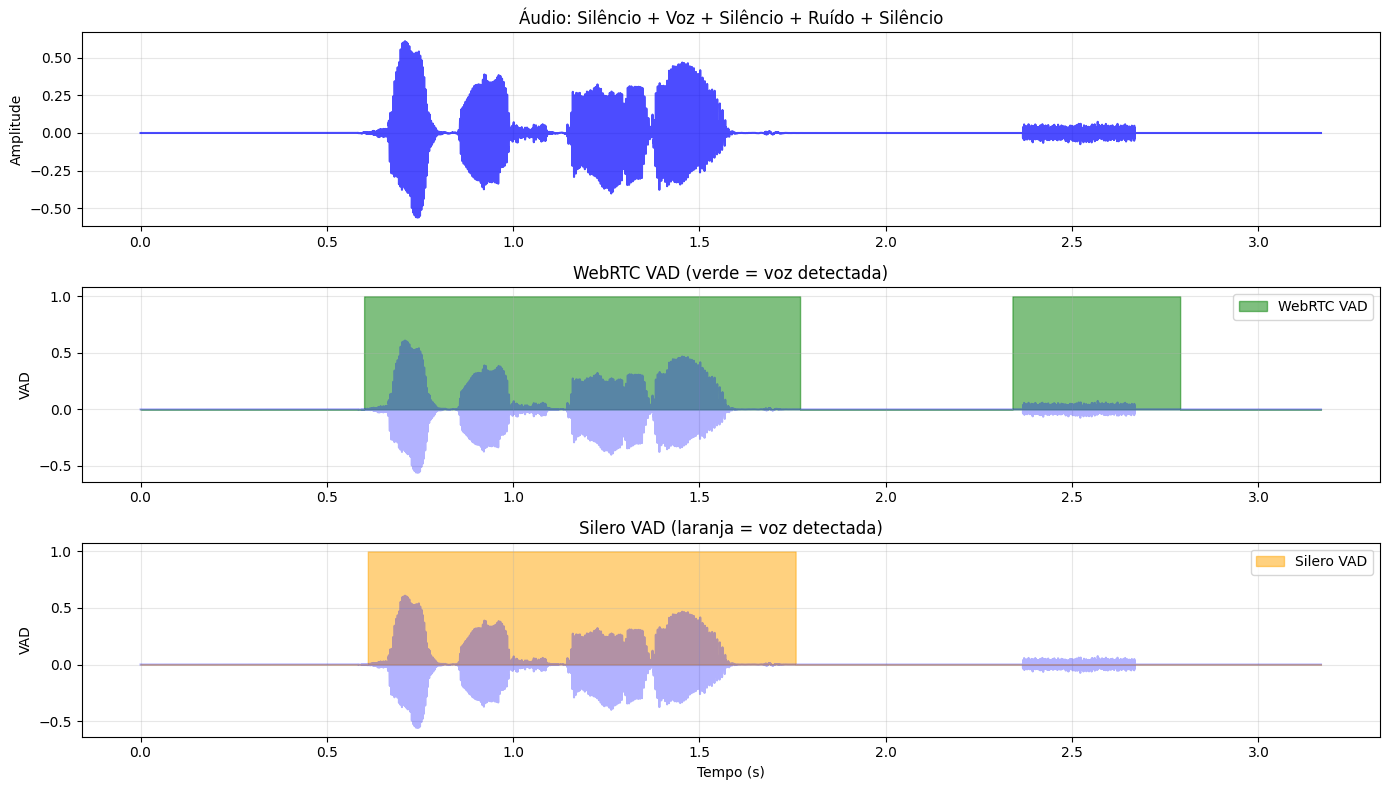

In [56]:
print("\n" + "=" * 70)
print("VISUALIZAÇÃO VAD")
print("=" * 70)

# Áudio com voz + silêncio
audio_mixed = np.concatenate([
    generate_silence(0.5),
    generate_test_audio("Help me stand up"),
    generate_silence(0.5),
    generate_noise(0.3, amplitude=0.02),
    generate_silence(0.5),
])

# Analisar com ambos os métodos
_, _, webrtc_frames = vad_webrtc(audio_mixed, aggressiveness=2)
_, silero_ratio, silero_timestamps = vad_silero(audio_mixed)

# Criar máscara Silero
silero_mask = np.zeros(len(audio_mixed))
for ts in silero_timestamps:
    silero_mask[ts['start']:ts['end']] = 1

# Expandir webrtc_frames para visualização
frame_size = int(16000 * 30 / 1000)
webrtc_mask = np.zeros(len(audio_mixed))
for i, is_speech in enumerate(webrtc_frames):
    start = i * frame_size
    end = min(start + frame_size, len(audio_mixed))
    if is_speech:
        webrtc_mask[start:end] = 1

# Gráfico
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

t = np.linspace(0, len(audio_mixed)/16000, len(audio_mixed))

# Áudio
axes[0].plot(t, audio_mixed, color='blue', alpha=0.7)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Áudio: Silêncio + Voz + Silêncio + Ruído + Silêncio')
axes[0].grid(True, alpha=0.3)

# WebRTC VAD
axes[1].fill_between(t, webrtc_mask, alpha=0.5, color='green', label='WebRTC VAD')
axes[1].plot(t, audio_mixed, color='blue', alpha=0.3)
axes[1].set_ylabel('VAD')
axes[1].set_title('WebRTC VAD (verde = voz detectada)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Silero VAD
axes[2].fill_between(t, silero_mask, alpha=0.5, color='orange', label='Silero VAD')
axes[2].plot(t, audio_mixed, color='blue', alpha=0.3)
axes[2].set_xlabel('Tempo (s)')
axes[2].set_ylabel('VAD')
axes[2].set_title('Silero VAD (laranja = voz detectada)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vad_comparison.png', dpi=150)
plt.show()


## PIPELINE COM VAD


In [57]:
print("\n" + "=" * 70)
print("PIPELINE COMPLETO COM VAD")
print("=" * 70)

# Nota: client Groq já carregado nas seções anteriores

SYSTEM_PROMPT_VAD = """You are an AI for a caregiving robot. Classify if speech is ADDRESSED to you or NOT_ADDRESSED. 
Respond in JSON: {"classification": "ADDRESSED" or "NOT_ADDRESSED", "confidence": "HIGH/MEDIUM/LOW", "response": "helpful response if ADDRESSED, null otherwise"}"""


def pipeline_with_vad(audio_array, sr=16000, vad_type="webrtc"):
    """Pipeline completo: VAD → Whisper → LLM."""
    
    result = {
        "vad_detected": False,
        "transcription": None,
        "classification": None,
        "response": None,
        "times": {}
    }
    
    # 1. VAD
    start = time.time()
    if vad_type == "webrtc":
        has_speech, speech_ratio, _ = vad_webrtc(audio_array)
    else:
        has_speech, speech_ratio, _ = vad_silero(audio_array)
    result["times"]["vad"] = (time.time() - start) * 1000
    result["vad_detected"] = has_speech
    result["speech_ratio"] = speech_ratio
    
    # Se não há voz, terminar aqui
    if not has_speech:
        result["times"]["total"] = result["times"]["vad"]
        return result
    
    # 2. Whisper STT
    start = time.time()
    temp_path = "/tmp/temp_audio.wav"
    sf.write(temp_path, audio_array, sr)
    
    with open(temp_path, "rb") as f:
        transcription = client.audio.transcriptions.create(
            model="whisper-large-v3-turbo",
            file=f,
            language="en"
        )
    result["transcription"] = transcription.text
    result["times"]["whisper"] = (time.time() - start) * 1000
    
    # 3. LLM
    start = time.time()
    
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_VAD},
            {"role": "user", "content": f"Speech: \"{result['transcription']}\""}
        ],
        temperature=0.1,
        max_tokens=200
    )
    
    llm_result = response.choices[0].message.content
    llm_result = llm_result.replace("```json", "").replace("```", "").strip()
    
    try:
        parsed = json.loads(llm_result)
        result["classification"] = parsed.get("classification")
        result["confidence"] = parsed.get("confidence")
        result["response"] = parsed.get("response")
    except:
        result["classification"] = "ERROR"
    
    result["times"]["llm"] = (time.time() - start) * 1000
    result["times"]["total"] = result["times"]["vad"] + result["times"]["whisper"] + result["times"]["llm"]
    
    return result



PIPELINE COMPLETO COM VAD


In [ ]:
print("\nTestando pipeline com VAD...\n")

PIPELINE_TESTS = [
    ("Voz: solicitação", generate_test_audio("Please help me stand up")),
    ("Voz: pensamento", generate_test_audio("I wonder where my glasses are")),
    ("Silêncio puro", generate_silence(2.0)),
    ("Apenas ruído", generate_noise(2.0, amplitude=0.05)),
]

print(f"{'Caso':<25} {'VAD':<10} {'Classificação':<20} {'Tempo Total':<15}")
print("-" * 70)

for name, audio in PIPELINE_TESTS:
    result = pipeline_with_vad(audio, vad_type="webrtc")
    
    vad_str = "VOZ" if result["vad_detected"] else "SEM VOZ"
    class_str = result["classification"] if result["classification"] else "-"
    time_str = f"{result['times']['total']:.0f}ms"
    
    print(f"{name:<25} {vad_str:<10} {class_str:<20} {time_str:<15}")
    
    if result["vad_detected"]:
        print(f"  → Transcrição: \"{result.get('transcription', '')[:50]}...\"")
        if result.get("response"):
            print(f"  → Resposta: \"{result['response'][:50]}...\"")




Testando pipeline com VAD...

Caso                      VAD        Classificação        Tempo Total    
----------------------------------------------------------------------
Voz: solicitação          VOZ        ADDRESSED            1005ms         
  → Transcrição: " Please help me stand up...."
  → Resposta: "Here to assist you.  Please hold onto my arm for s..."
Voz: pensamento           VOZ        NOT_ADDRESSED        865ms          
  → Transcrição: " I wonder where my glasses are...."
Silêncio puro             SEM VOZ    -                    0ms            
Apenas ruído              VOZ        NOT_ADDRESSED        981ms          
  → Transcrição: " ...."


# ============================================
# AVALIAÇÃO FINAL: 10 CASOS REAIS
# Pipeline: VAD → Whisper → LLM
# ============================================

### AVALIAÇÃO FINAL

In [59]:
SYSTEM_PROMPT_FINAL = """You are an AI for a caregiving robot helping people with disabilities in a smart home.

The robot assists people without hands/arms, elderly with mobility issues, visually/hearing impaired.

The robot can: physical assistance, IoT control, bring objects, communication, companionship, emergency help.

Classify if speech is ADDRESSED to you (expecting response/action) or NOT_ADDRESSED (thinking aloud, talking to others, TV/radio).

Respond ONLY in JSON:
{"classification": "ADDRESSED" or "NOT_ADDRESSED", "confidence": "HIGH/MEDIUM/LOW", "reasoning": "brief explanation", "response": "helpful response if ADDRESSED, null otherwise"}"""

# %%
# FUNÇÕES DO PIPELINE FINAL

def generate_audio_final(text, sr=16000):
    """Gera áudio com gTTS para avaliação final."""
    tts = gTTS(text=text, lang='en')
    fp = io.BytesIO()
    tts.write_to_fp(fp)
    fp.seek(0)
    audio, orig_sr = sf.read(fp)
    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)
    if orig_sr != sr:
        audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=sr)
    return audio.astype(np.float32)


def vad_check_final(audio_array, sr=16000, aggressiveness=2):
    """VAD com WebRTC para avaliação final."""
    vad = webrtcvad.Vad(aggressiveness)
    audio_int16 = (audio_array * 32767).astype(np.int16)
    frame_size = int(sr * 30 / 1000)
    
    speech_frames = 0
    total_frames = len(audio_int16) // frame_size
    
    for i in range(total_frames):
        start = i * frame_size
        frame = audio_int16[start:start + frame_size].tobytes()
        try:
            if vad.is_speech(frame, sr):
                speech_frames += 1
        except:
            pass
    
    speech_ratio = speech_frames / total_frames if total_frames > 0 else 0
    return speech_ratio > 0.1, speech_ratio


def transcribe_final(audio_array, sr=16000):
    """Transcreve com Whisper para avaliação final."""
    temp_path = "/tmp/eval_audio.wav"
    sf.write(temp_path, audio_array, sr)
    
    with open(temp_path, "rb") as f:
        result = client.audio.transcriptions.create(
            model="whisper-large-v3-turbo",
            file=f,
            language="en"
        )
    return result.text.strip()


def classify_final(text):
    """Classifica com LLM para avaliação final."""
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_FINAL},
            {"role": "user", "content": f"Speech: \"{text}\""}
        ],
        temperature=0.1,
        max_tokens=250
    )
    
    result = response.choices[0].message.content
    result = result.replace("```json", "").replace("```", "").strip()
    
    try:
        return json.loads(result)
    except:
        return {"classification": "ERROR", "confidence": "LOW", "reasoning": "Erro de parse", "response": None}


def run_pipeline_final(audio_array, sr=16000):
    """Pipeline completo para avaliação final."""
    result = {"times": {}}
    
    # VAD
    start = time.time()
    has_speech, speech_ratio = vad_check_final(audio_array, sr)
    result["times"]["vad"] = (time.time() - start) * 1000
    result["has_speech"] = has_speech
    result["speech_ratio"] = speech_ratio
    
    if not has_speech:
        result["classification"] = "NO_SPEECH"
        result["times"]["total"] = result["times"]["vad"]
        return result
    
    # Whisper
    start = time.time()
    result["transcription"] = transcribe_final(audio_array, sr)
    result["times"]["whisper"] = (time.time() - start) * 1000
    
    # LLM
    start = time.time()
    llm_result = classify_final(result["transcription"])
    result["times"]["llm"] = (time.time() - start) * 1000
    
    result["classification"] = llm_result.get("classification")
    result["confidence"] = llm_result.get("confidence")
    result["reasoning"] = llm_result.get("reasoning")
    result["response"] = llm_result.get("response")
    result["times"]["total"] = result["times"]["vad"] + result["times"]["whisper"] + result["times"]["llm"]
    
    return result


### 10 CASOS DE TESTE REALISTAS


In [60]:
print("=" * 80)
print("AVALIACAO FINAL: 10 CASOS REAIS")
print("Robo Assistencial - Pipeline VAD -> Whisper -> LLM")
print("=" * 80)

TEST_CASES_FINAL = [
    # === ADDRESSED (5 casos) ===
    {
        "id": 1,
        "text": "Robot can you please help me get out of bed",
        "expected": "ADDRESSED",
        "scenario": "Usuário idoso com mobilidade reduzida olhando para o robô, pedindo ajuda física"
    },
    {
        "id": 2,
        "text": "Turn off the lights and close the window please",
        "expected": "ADDRESSED",
        "scenario": "Usuário sem mãos dando comandos IoT ao robô"
    },
    {
        "id": 3,
        "text": "I am feeling very lonely today can we talk for a while",
        "expected": "ADDRESSED",
        "scenario": "Usuário idoso olhando para o robô, buscando companhia"
    },
    {
        "id": 4,
        "text": "What time is my doctor appointment tomorrow",
        "expected": "ADDRESSED",
        "scenario": "Usuário com deficiência visual perguntando ao robô sobre sua agenda"
    },
    {
        "id": 5,
        "text": "Please call my daughter I need to speak with her urgently",
        "expected": "ADDRESSED",
        "scenario": "Usuário sem mãos solicitando fazer uma ligação"
    },
    
    # === NOT_ADDRESSED (5 casos) ===
    {
        "id": 6,
        "text": "I wonder if my son will visit me this weekend",
        "expected": "NOT_ADDRESSED",
        "scenario": "Usuário olhando pela janela, pensando em voz alta"
    },
    {
        "id": 7,
        "text": "Yes doctor I have been taking my medication every day",
        "expected": "NOT_ADDRESSED",
        "scenario": "Usuário falando ao telefone com seu médico"
    },
    {
        "id": 8,
        "text": "Can you give me an apple",
        "expected": "NOT_ADDRESSED",
        "scenario": "Televisão ligada com notícias de fundo enquanto usuário parece dormir"
    },
    {
        "id": 9,
        "text": "Come here boy good dog sit down now",
        "expected": "NOT_ADDRESSED",
        "scenario": "Usuário dando comandos ao seu animal de estimação"
    },
    {
        "id": 10,
        "text": "Tell your mother I hope she feels better soon",
        "expected": "NOT_ADDRESSED",
        "scenario": "Usuário se despedindo de um visitante humano"
    },
]

# %%
# EXECUTAR AVALIAÇÃO

final_results = []

print("\n" + "-" * 80)

for case in TEST_CASES_FINAL:
    print(f"\n[CASO {case['id']}]: {case['expected']}")
    print(f"   Cenário: {case['scenario']}")
    print(f"   Texto: \"{case['text']}\"")
    
    # Gerar áudio e executar pipeline
    audio = generate_audio_final(case['text'])
    result = run_pipeline_final(audio)
    
    # Verificar resultado
    correct = result["classification"] == case["expected"]
    
    final_results.append({
        "id": case["id"],
        "text": case["text"],
        "expected": case["expected"],
        "predicted": result["classification"],
        "confidence": result.get("confidence", "N/A"),
        "reasoning": result.get("reasoning", ""),
        "response": result.get("response"),
        "correct": correct,
        "time_ms": result["times"]["total"]
    })
    
    # Mostrar resultado
    status = "[CORRETO]" if correct else "[INCORRETO]"
    print(f"\n   Resultado: {result['classification']} ({result.get('confidence', 'N/A')}) {status}")
    print(f"   Raciocínio: {result.get('reasoning', 'N/A')}")
    print(f"   Tempo: {result['times']['total']:.0f}ms")
    
    if result["classification"] == "ADDRESSED" and result.get("response"):
        print(f"   Resposta: \"{result['response']}\"")
    
    print("-" * 80)


AVALIACAO FINAL: 10 CASOS REAIS
Robo Assistencial - Pipeline VAD -> Whisper -> LLM

--------------------------------------------------------------------------------

[CASO 1]: ADDRESSED
   Cenário: Usuário idoso com mobilidade reduzida olhando para o robô, pedindo ajuda física
   Texto: "Robot can you please help me get out of bed"

   Resultado: ADDRESSED (HIGH) [CORRETO]
   Raciocínio: Direct request for assistance
   Tempo: 1132ms
   Resposta: "I'm here to help. I'll gently assist you out of bed. Please hold on to the bed rails and I'll carefully lift you up."
--------------------------------------------------------------------------------

[CASO 2]: ADDRESSED
   Cenário: Usuário sem mãos dando comandos IoT ao robô
   Texto: "Turn off the lights and close the window please"

   Resultado: ADDRESSED (HIGH) [CORRETO]
   Raciocínio: Direct request to perform a specific action
   Tempo: 1049ms
   Resposta: "Lights turned off and window closed."
------------------------------------------

### MÉTRICAS FINAIS


In [ ]:
print("\n" + "=" * 80)
print("RESULTADOS FINAIS")
print("=" * 80)

# Accuracy
correct_count = sum(r["correct"] for r in final_results)
total = len(final_results)
accuracy = correct_count / total

# Por classe
addressed_results = [r for r in final_results if r["expected"] == "ADDRESSED"]
not_addressed_results = [r for r in final_results if r["expected"] == "NOT_ADDRESSED"]

addressed_correct = sum(r["correct"] for r in addressed_results)
not_addressed_correct = sum(r["correct"] for r in not_addressed_results)

# Tempos
avg_time = np.mean([r["time_ms"] for r in final_results])

print(f"""
+-------------------------------------------------------------------+
|                    MÉTRICAS DE AVALIAÇÃO                          |
+-------------------------------------------------------------------+
|  Accuracy Total:     {correct_count}/{total} ({accuracy:.0%})                                |
|                                                                   |
|  ADDRESSED:          {addressed_correct}/{len(addressed_results)} corretos                              |
|  NOT_ADDRESSED:      {not_addressed_correct}/{len(not_addressed_results)} corretos                              |
|                                                                   |
|  Latência Média:     {avg_time:.0f}ms                                       |
+-------------------------------------------------------------------+
""")

# Tabela de resultados
print("\nTABELA DE RESULTADOS:")
print(f"{'ID':<4} {'Esperado':<15} {'Predito':<15} {'Conf':<8} {'Tempo':<10} {'OK?'}")
print("-" * 60)

for r in final_results:
    status = "[OK]" if r["correct"] else "[X]"
    print(f"{r['id']:<4} {r['expected']:<15} {r['predicted']:<15} {r['confidence']:<8} {r['time_ms']:.0f}ms      {status}")

# Análise de erros
errors = [r for r in final_results if not r["correct"]]

if errors:
    print(f"\nANÁLISE DE ERROS ({len(errors)} erros):")
    for e in errors:
        print(f"\n   Caso {e['id']}: \"{e['text'][:50]}...\"")
        print(f"   Esperado: {e['expected']} -> Predito: {e['predicted']}")
        print(f"   Raciocínio: {e['reasoning']}")
else:
    print("\nSEM ERROS - Todos os casos classificados corretamente!")



RESULTADOS FINAIS

+-------------------------------------------------------------------+
|                    MÉTRICAS DE AVALIAÇÃO                          |
+-------------------------------------------------------------------+
|  Accuracy Total:     9/10 (90%)                                |
|                                                                   |
|  ADDRESSED:          5/5 corretos                              |
|  NOT_ADDRESSED:      4/5 corretos                              |
|                                                                   |
|  Latência Média:     1544ms                                       |
+-------------------------------------------------------------------+


TABELA DE RESULTADOS:
ID   Esperado        Predito         Conf     Tempo      OK?
------------------------------------------------------------
1    ADDRESSED       ADDRESSED       HIGH     1132ms      [OK]
2    ADDRESSED       ADDRESSED       HIGH     1049ms      [OK]
3    ADDRESSED   